# scGPT Fine-tuning and Cell Embedding Extraction Pipeline

Author: Tengxiao Gao

Overview:
This notebook implements a complete workflow for applying a pretrained
scGPT model to single-cell RNA-seq data, including optional fine-tuning
and downstream embedding extraction.

The goal is to adapt the pretrained scGPT model to a specific dataset
(e.g. retina) and generate biologically meaningful cell embeddings for
further analysis.

Pipeline:
1. Load pretrained scGPT model and vocabulary
2. Map genes to token IDs based on the vocabulary
3. Prepare input sequences from gene expression data
4. (Optional) Fine-tune the model using masked value prediction
5. Extract cell embeddings using the fine-tuned model
6. Store embeddings in AnnData for downstream analysis

Key features:
- Efficient batching with support for sparse matrices
- Mixed precision training (optional, CUDA only)
- Masked value prediction for fine-tuning
- CLS-based cell embedding extraction
- GPU memory-aware design (small batch, cache clearing)

Inputs:
- AnnData object containing gene expression matrix (adata.X or layers['counts'])
- Pretrained scGPT checkpoint (args.json, vocab.json, model weights)
- Gene vocabulary (GeneVocab)

Outputs:
- Fine-tuned model (optional)
- Cell embeddings stored in `adata.obsm["X_scGPT_finetuned"]`
- Saved AnnData file for downstream analysis

Notes:
- Start with small batch size and sequence length on limited GPUs (e.g. T4)
- Fine-tuning is optional but may improve dataset-specific representations
- Results can be used for clustering, visualization, or integration comparison


In [1]:
import os
import anndata as ad

DATA_PATH = "/home/ubuntu/sclecture_fm_benchmark/notebooks/explore/data/cxg/retina_ganglion_ex_midget.h5ad"
CKPT_DIR  = "/home/ubuntu/sclecture_fm_benchmark/save/scGPT_human"

adata = ad.read_h5ad(DATA_PATH)
print(adata)
print("X:", type(adata.X), "shape:", adata.shape)

AnnData object with n_obs × n_vars = 20587 × 35475
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'RGC_celltype_number', 'study_name', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 

In [2]:
import torch, sys
print("python:", sys.version)
print("torch:", torch.__version__)


python: 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:29:10) [GCC 14.3.0]
torch: 2.3.1+cu118


In [3]:
import torch
import scgpt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

import torchtext
print("torchtext:", torchtext.__version__)

/vol/data/conda_envs/scgpt/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/vol/data/conda_envs/scgpt/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/vol/data/conda_envs/scgpt/lib/python3.10/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/vol/data/conda_envs/scgpt/lib/python3.10/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (

torch: 2.3.1+cu118
cuda available: True
torchtext: 0.18.0+cpu


In [4]:
import sys, site
print("python:", sys.executable)
print("prefix:", sys.prefix)
print("site-packages:", site.getsitepackages()[:2])

python: /vol/data/conda_envs/scgpt/bin/python
prefix: /vol/data/conda_envs/scgpt
site-packages: ['/vol/data/conda_envs/scgpt/lib/python3.10/site-packages']


In [5]:
import sys
print(sys.executable)

/vol/data/conda_envs/scgpt/bin/python


In [6]:
import torch, torchtext
print("torch:", torch.__version__)
print("torchtext:", torchtext.__version__)

import scgpt
print("scgpt import OK")

torch: 2.3.1+cu118
torchtext: 0.18.0+cpu
scgpt import OK


In [7]:
CKPT_DIR = "/home/ubuntu/sclecture_fm_benchmark/save/scGPT_human"  # there are best_model.pt / args.json / vocab.json
DATA_PATH = "/home/ubuntu/sclecture_fm_benchmark/notebooks/explore/data/cxg/retina_ganglion_ex_midget.h5ad"

In [8]:
import os, json
from pathlib import Path

print("CKPT exists:", Path(CKPT_DIR).exists())
print("CKPT files:", sorted([p.name for p in Path(CKPT_DIR).iterdir()]))

print("DATA exists:", Path(DATA_PATH).exists())

CKPT exists: True
CKPT files: ['args.json', 'best_model.pt', 'vocab.json']
DATA exists: True


In [9]:
import anndata as ad
import numpy as np
import scipy.sparse as sp

adata = ad.read_h5ad(DATA_PATH)

# Select count matrix: use adata.layers['counts'] if available, otherwise use adata.X
if "counts" in adata.layers:
    X = adata.layers["counts"]
else:
    X = adata.X

# scGPT prefer CSR sparse
if sp.issparse(X):
    X = X.tocsr()
else:
    X = sp.csr_matrix(X)

print("adata:", adata)
print("X:", X.shape, "nnz:", X.nnz)
print("var_names example:", adata.var_names[:5].tolist())

adata: AnnData object with n_obs × n_vars = 20587 × 35475
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'RGC_celltype_number', 'study_name', 'nCount_RNA', 'nFeature_RNA', 'percen

In [10]:
import json
from pathlib import Path

CKPT = Path(CKPT_DIR)

with open(CKPT / "args.json", "r") as f:
    args = json.load(f)

with open(CKPT / "vocab.json", "r") as f:
    vocab = json.load(f)

print("args keys:", list(args.keys())[:20])
print("vocab size:", len(vocab))
print("example vocab items:", list(vocab.items())[:3])

args keys: ['data_source', 'save_dir', 'load_model', 'n_hvg', 'valid_size_or_ratio', 'dist_backend', 'grad_accu_steps', 'pad_token', 'input_style', 'input_emb_style', 'n_bins', 'max_seq_len', 'training_tasks', 'dist_url', 'mask_ratio', 'trunc_by_sample', 'vocab_path', 'rank', 'batch_size', 'eval_batch_size']
vocab size: 60697
example vocab items: [('RP5-973N23.5', 60693), ('RP11-182N22.10', 60689), ('CTB-53D8.3', 60687)]


In [11]:
# Common vocab.json formats: gene->id or id->gene
# We standardize to gene->id
if all(isinstance(k, str) and k.isdigit() for k in list(vocab.keys())[:5]):
    # Detected id->gene format, convert it to gene->id
    gene2id = {v: int(k) for k, v in vocab.items()}
else:
    gene2id = {k: int(v) for k, v in vocab.items()}

genes = adata.var_names.astype(str).to_numpy()
gene_ids = np.array([gene2id.get(g, gene2id.get("<unk>", -1)) for g in genes], dtype=int)

valid = gene_ids >= 0
print("genes in vocab:", valid.sum(), "/", len(genes))
print("first 10 gene_ids:", gene_ids[:10])

genes in vocab: 0 / 35475
first 10 gene_ids: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


In [12]:
import json
from pathlib import Path
import torch

from scgpt.model import TransformerModel
from scgpt.tokenizer import GeneVocab

CKPT = Path("/home/ubuntu/sclecture_fm_benchmark/save/scGPT_human")

# 1) Load config (args) and vocabulary
args = json.load(open(CKPT / "args.json"))
vocab = GeneVocab.from_file(CKPT / "vocab.json")

pad_token = args.get("pad_token", "<pad>")  # must be a string
print("pad_token:", pad_token, "in vocab?", pad_token in vocab)

# 2) Extract model hyperparameters from args (with fallback for compatibility)
d_model  = args.get("d_model",  args.get("embsize", 512))
n_head   = args.get("n_head",   args.get("nheads", 8))
d_ff     = args.get("d_ff",     args.get("d_hid", 512))
n_layer  = args.get("n_layer",  args.get("nlayers", 12))
dropout  = args.get("dropout",  0.2)

print("model cfg:", dict(
    n_layer=n_layer,
    n_head=n_head,
    d_model=d_model,
    d_ff=d_ff,
    dropout=dropout,
    vocab_size=len(vocab)
))

# 3) Initialize model correctly:
#    pass vocab object and pad_token string
model = TransformerModel(
    ntoken=len(vocab),
    d_model=d_model,
    nhead=n_head,
    d_hid=d_ff,
    nlayers=n_layer,
    dropout=dropout,
    vocab=vocab,
    pad_token=pad_token,
)

# 4) Load checkpoint
state = torch.load(CKPT / "best_model.pt", map_location="cpu")

# Handle different checkpoint formats
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
if isinstance(state, dict) and "model_state_dict" in state:
    state = state["model_state_dict"]

missing, unexpected = model.load_state_dict(state, strict=False)
print("missing:", len(missing), "unexpected:", len(unexpected))

# Move model to device
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device).eval()
print("device:", device)

pad_token: <pad> in vocab? True
model cfg: {'n_layer': 12, 'n_head': 8, 'd_model': 512, 'd_ff': 512, 'dropout': 0.2, 'vocab_size': 60697}
missing: 34 unexpected: 28
device: cuda


In [13]:
import anndata as ad
import numpy as np
import scipy.sparse as sp

from pathlib import Path

DATA_PATH = Path("/home/ubuntu/sclecture_fm_benchmark/notebooks/explore/data/cxg/retina_ganglion_ex_midget.h5ad")
adata = ad.read_h5ad(DATA_PATH)
print(adata)
print("X:", type(adata.X), adata.X.shape)
print("var_name example:", adata.var_names[:5].tolist())

AnnData object with n_obs × n_vars = 20587 × 35475
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'RGC_celltype_number', 'study_name', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 

In [14]:
# vocab is the GeneVocab object loaded in the previous step
genes = adata.var["feature_name"].astype(str).values

in_vocab = np.array([g in vocab for g in genes], dtype=bool)
print("genes in vocab:", in_vocab.sum(), "/", len(in_vocab))

adata2 = adata[:, in_vocab].copy()
print("filtered adata:", adata2.shape)

genes in vocab: 24015 / 35475
filtered adata: (20587, 24015)


In [15]:
import numpy as np
import scipy.sparse as sp

X = adata2.X
if sp.issparse(X):
    X = X.tocsr()

genes = adata2.var["feature_name"].astype(str).values  # gene symbol
print("X shape:", X.shape, "genes:", len(genes))
print("example genes:", genes[:5])

X shape: (20587, 24015) genes: 24015
example genes: ['MIR1302-2HG' 'FAM138A' 'OR4F5' 'OR4F29' 'OR4F16']


In [16]:
import torch

# vocab: GeneVocab object (already loaded in the previous step)
pad_id = vocab["<pad>"] if "<pad>" in vocab else vocab["<pad>"]  # general exists
unk_id = vocab["<unk>"] if "<unk>" in vocab else None

gene_ids = np.array([vocab[g] if g in vocab else (unk_id if unk_id is not None else pad_id) for g in genes], dtype=np.int64)
print("gene_ids:", gene_ids.shape, "min/max:", gene_ids.min(), gene_ids.max())

gene_ids: (24015,) min/max: 0 55397


In [17]:
B = 2
cell_idx = np.arange(min(B, adata2.n_obs))
Xb = X[cell_idx]

# Convert to dense format (B x G); B = 64 is totally fine
if sp.issparse(Xb):
    Xb = Xb.toarray()
Xb = Xb.astype(np.float32)

device = "cuda" if torch.cuda.is_available() else "cpu"

gene_ids_t = torch.tensor(gene_ids, device=device)              # (G,)
expr_t = torch.tensor(Xb, device=device)                        # (B, G)

print("device:", device, "expr_t:", expr_t.shape, "gene_ids_t:", gene_ids_t.shape)

device: cuda expr_t: torch.Size([2, 24015]) gene_ids_t: torch.Size([24015])


In [18]:
import torch

B, G = expr_t.shape

# 1) Ensure correct dtype and shape
values = expr_t.to(device=device, dtype=torch.float32)         # [B, G]
gene_ids = gene_ids_t.to(device=device, dtype=torch.long)      # [G]

# 2) Construct src and mask
src_bs = gene_ids.unsqueeze(0).repeat(B, 1)                    # [B, G]
mask_bs = torch.zeros((B, G), device=device, dtype=torch.bool) # [B, G], all False = no masking

# 3) First try batch-first format [B, G]; if it fails, fall back to seq-first [G, B]
with torch.no_grad():
    try:
        out = model(
            src=src_bs,
            values=values,
            src_key_padding_mask=mask_bs,
            batch_labels=None,
            CLS=True,   # enable when extracting cell embeddings
        )
        mode = "BS"  # batch-first
    except Exception as e1:
        print("BS failed -> try SB. error:", repr(e1))
        out = model(
            src=src_bs.T.contiguous(),        # [G, B]
            values=values.T.contiguous(),     # [G, B]
            src_key_padding_mask=mask_bs,     # still [B, G]
            batch_labels=None,
            CLS=True,
        )
        mode = "SB"  # sequence-first

print("forward mode:", mode)
print("out type:", type(out))
print("out keys:", list(out.keys()))

for k, v in out.items():
    if torch.is_tensor(v):
        print(k, v.shape, v.dtype, v.device)

/vol/data/conda_envs/scgpt/lib/python3.10/site-packages/torch/nn/modules/transformer.py:408: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


forward mode: BS
out type: <class 'dict'>
out keys: ['mlm_output', 'cell_emb', 'cls_output']
mlm_output torch.Size([2, 24015]) torch.float32 cuda:0
cell_emb torch.Size([2, 512]) torch.float32 cuda:0
cls_output torch.Size([2, 1]) torch.float32 cuda:0


In [19]:
import numpy as np

cell_emb_cpu = out["cell_emb"].detach().cpu().numpy()   # (B, 512)
print("cell_emb_cpu:", cell_emb_cpu.shape)

# Write embeddings back to the corresponding cells in adata2
adata2_sub = adata2[cell_idx].copy()
adata2_sub.obsm["X_scGPT"] = cell_emb_cpu

# Save a small output (only these cells) to verify the pipeline works
adata2_sub.write_h5ad("retina_scgpt_emb_B2.h5ad")
print("saved:", "retina_scgpt_emb_B2.h5ad")

cell_emb_cpu: (2, 512)
saved: retina_scgpt_emb_B2.h5ad


In [20]:
import numpy as np
import torch
import scipy.sparse as sp
import gc

In [21]:
# ========= Settings: start with a safe configuration =========
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device).eval()

MAX_LEN = 256      # start with 128/256; do not jump to 1024 directly
BATCH = 1          # start with 1 on T4; increase to 2/4 after it runs
USE_FLOAT16 = False

print("device:", device, "MAX_LEN:", MAX_LEN, "BATCH:", BATCH, "fp16:", USE_FLOAT16)

device: cuda MAX_LEN: 256 BATCH: 1 fp16: False


In [22]:
# ========= 1) gene -> token id (already done) =========
genes = adata.var["feature_name"].astype(str).values
in_vocab = np.array([g in vocab for g in genes], dtype=bool)

adata2 = adata[:, in_vocab].copy()
genes_in = genes[in_vocab]
token_ids = np.array([vocab[g] for g in genes_in], dtype=np.int64)  # (G_in,)

X = adata2.X
n = adata2.n_obs

assert "pad_token" in args, "no pad_token in args.json"
pad_token = args["pad_token"]
assert pad_token in vocab, f"pad_token {pad_token} not in vocab"
pad_token_id = vocab[pad_token]

print("adata2:", adata2.shape, "pad_token_id:", pad_token_id)

adata2: (20587, 24015) pad_token_id: 60694


In [23]:

# ========= 2) batch -> topk seq =========
def batch_to_topk_seq(Xb, token_ids, max_len, pad_id):
    """
    Xb: (B, G) dense float32
    token_ids: (G,) int64
    return:
      src:  (B, S) int64
      val:  (B, S) float32
      mask: (B, S) bool   True=padding
    """
    B, G = Xb.shape
    S = max_len
    src = np.full((B, S), pad_id, dtype=np.int64)
    val = np.zeros((B, S), dtype=np.float32)
    mask = np.ones((B, S), dtype=bool)

    for i in range(B):
        row = Xb[i]
        nz = np.nonzero(row)[0]
        if nz.size == 0:
            continue

        k = min(S, nz.size)
        # top-k by value
        top = nz[np.argpartition(row[nz], -k)[-k:]]
        top = top[np.argsort(row[top])[::-1]]

        src[i, :k] = token_ids[top]
        val[i, :k] = row[top].astype(np.float32)
        mask[i, :k] = False

    return src, val, mask

In [24]:
# ========= 3) Single-batch forward =========
import torch
import numpy as np

def run_one_batch(model, src_bs, val_bs, mask_bs, device="cuda", use_float16=False, debug=False):
    """
    src_bs : (B, S) int64
    val_bs : (B, S) float32
    mask_bs: (B, S) bool   True = padding
    """

    src = torch.from_numpy(src_bs).to(device=device, dtype=torch.long)      # (B, S)

    # Recommended: run with float32 first (use_float16=False)
    values = torch.from_numpy(val_bs).to(
        device=device,
        dtype=(torch.float16 if (use_float16 and device == "cuda") else torch.float32)
    )                                                                       # (B, S)

    mask = torch.from_numpy(mask_bs).to(device=device, dtype=torch.bool)    # (B, S)

    if debug:
        print(
            "DEBUG shapes -> src", tuple(src.shape),
            "values", tuple(values.shape),
            "mask", tuple(mask.shape),
            "dtypes", src.dtype, values.dtype, mask.dtype,
            "device", device
        )

    # Do NOT transpose: forward expects (B, S)
    out = model(
        src=src,
        values=values,
        src_key_padding_mask=mask,   # (B, S)
        batch_labels=None,
        CLS=True
    )

    emb = out["cell_emb"].detach().float().cpu().numpy()  # (B, 512)

    # Clean up
    del src, values, mask, out
    if device == "cuda":
        torch.cuda.empty_cache()

    return emb

In [25]:
# ========= 4) Main loop: full dataset =========
USE_FLOAT16 = False      # start with float32 for stability
MAX_LEN = 256            # recommended: 128/256 on T4
BATCH = 1                # start with batch size = 1

all_emb = []
n = adata2.n_obs

with torch.inference_mode():
    for start in range(0, n, BATCH):
        end = min(n, start + BATCH)

        Xb = X[start:end]
        if sp.issparse(Xb):
            Xb = Xb.toarray()
        Xb = Xb.astype(np.float32)

        src_bs, val_bs, mask_bs = batch_to_topk_seq(Xb, token_ids, MAX_LEN, pad_token_id)

        debug = (start == 0)
        emb = run_one_batch(model, src_bs, val_bs, mask_bs, device=device, use_float16=USE_FLOAT16, debug=debug)
        all_emb.append(emb)

all_emb = np.vstack(all_emb)
print("X_scGPT:", all_emb.shape)

adata2.obsm["X_scGPT"] = all_emb
adata2.write_h5ad("retina_scgpt_cell_emb.h5ad")
print("saved: retina_scgpt_cell_emb.h5ad")

DEBUG shapes -> src (1, 256) values (1, 256) mask (1, 256) dtypes torch.int64 torch.float32 torch.bool device cuda
X_scGPT: (20587, 512)
saved: retina_scgpt_cell_emb.h5ad


In [26]:
import gc, torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [27]:
import torch
import numpy as np
import scipy.sparse as sp
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device).train()   # switch to training mode (required for fine-tuning)

MAX_LEN = 256          # keep small for stability (256 works on T4)
BATCH = 1              # start with batch size = 1 on T4
MASK_FRAC = 0.15       # masking ratio
LR = 1e-4              # small learning rate
STEPS = 200            # run ~200 steps to verify fine-tuning works (can increase later)
LOG_EVERY = 20

# —— Freeze all parameters —— #
for p in model.parameters():
    p.requires_grad = False

# —— Unfreeze only a small subset (recommended: value_encoder + normalization/decoder-related layers) —— #
train_keywords = ["value_encoder", "decoder", "mlm", "norm", "ln", "cls"]
trainable = []

for n, p in model.named_parameters():
    if any(k in n.lower() for k in train_keywords):
        p.requires_grad = True
        trainable.append(n)

print("Trainable params (count):", sum(p.requires_grad for p in model.parameters()))
print("Example trainable names (first 30):")
for n in trainable[:30]:
    print("  ", n)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR
)

scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

Trainable params (count): 72
Example trainable names (first 30):
   encoder.enc_norm.weight
   encoder.enc_norm.bias
   value_encoder.linear1.weight
   value_encoder.linear1.bias
   value_encoder.linear2.weight
   value_encoder.linear2.bias
   value_encoder.norm.weight
   value_encoder.norm.bias
   transformer_encoder.layers.0.norm1.weight
   transformer_encoder.layers.0.norm1.bias
   transformer_encoder.layers.0.norm2.weight
   transformer_encoder.layers.0.norm2.bias
   transformer_encoder.layers.1.norm1.weight
   transformer_encoder.layers.1.norm1.bias
   transformer_encoder.layers.1.norm2.weight
   transformer_encoder.layers.1.norm2.bias
   transformer_encoder.layers.2.norm1.weight
   transformer_encoder.layers.2.norm1.bias
   transformer_encoder.layers.2.norm2.weight
   transformer_encoder.layers.2.norm2.bias
   transformer_encoder.layers.3.norm1.weight
   transformer_encoder.layers.3.norm1.bias
   transformer_encoder.layers.3.norm2.weight
   transformer_encoder.layers.3.norm2.bias

In [28]:
def make_masked_values(val_bs, mask_bs, mask_frac=0.15):
    """
    val_bs : (B, S) float32
    mask_bs: (B, S) bool, True = padding

    Returns:
      val_in   : (B, S) float32  input values for the model (masked positions set to 0)
      target   : (B, S) float32  original values (used as targets)
      pred_mask: (B, S) bool     positions used for loss (masked and not padding)
    """
    B, S = val_bs.shape
    target = val_bs.copy()

    not_pad = ~mask_bs
    pred_mask = np.zeros((B, S), dtype=bool)

    rng = np.random.default_rng()
    for i in range(B):
        idx = np.where(not_pad[i])[0]
        if idx.size == 0:
            continue
        m = max(1, int(mask_frac * idx.size))
        chosen = rng.choice(idx, size=m, replace=False)
        pred_mask[i, chosen] = True

    val_in = val_bs.copy()
    val_in[pred_mask] = 0.0

    return val_in, target, pred_mask

In [29]:
def run_one_batch_finetune(model, src_bs, val_bs, mask_bs, device="cuda", mask_frac=0.15):
    """
    Perform one fine-tuning step with masked value prediction.

    - Randomly masks a subset of input values
    - Computes regression loss only on masked positions
    """

    # Generate masked input / target / prediction mask
    val_in, target, pred_mask = make_masked_values(val_bs, mask_bs, mask_frac=mask_frac)

    # numpy -> torch (B, S)
    src = torch.from_numpy(src_bs).to(device=device, dtype=torch.long)
    values = torch.from_numpy(val_in).to(device=device, dtype=torch.float32)   # keep float32, let autocast handle precision
    key_padding_mask = torch.from_numpy(mask_bs).to(device=device, dtype=torch.bool)

    target_t = torch.from_numpy(target).to(device=device, dtype=torch.float32)
    pred_mask_t = torch.from_numpy(pred_mask).to(device=device, dtype=torch.bool)

    # Sanity check
    assert src.shape == values.shape == key_padding_mask.shape, (
        src.shape, values.shape, key_padding_mask.shape
    )

    # Mixed precision (enabled only on CUDA)
    with torch.cuda.amp.autocast(enabled=(device == "cuda")):
        out = model(
            src=src,                       # (B, S)
            values=values,                 # (B, S)
            src_key_padding_mask=key_padding_mask,  # (B, S)
            batch_labels=None,
            CLS=False
        )

        pred = out["mlm_output"]          # expected shape: (B, S)

        # Compute loss only on masked positions
        loss = F.mse_loss(pred[pred_mask_t], target_t[pred_mask_t])

    return loss, out

In [30]:
# data preparation
X = adata2.X
n = adata2.n_obs

model.train()
step = 0
loss_hist = []
step_hist = []

while step < STEPS:
    # pick batch of cell randomly（Faster to observe loss decreasing than sequential scanning）
    idx = np.random.choice(n, size=min(BATCH, n), replace=False)
    Xb = X[idx]
    if sp.issparse(Xb):
        Xb = Xb.toarray()
    Xb = Xb.astype(np.float32)

    # (B,S)
    src_bs, val_bs, mask_bs = batch_to_topk_seq(Xb, token_ids, MAX_LEN, pad_token_id)

    optimizer.zero_grad(set_to_none=True)

    loss, _ = run_one_batch_finetune(
        model, src_bs, val_bs, mask_bs,
        device=device, mask_frac=MASK_FRAC
    )

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    loss_hist.append(float(loss.detach().cpu()))
    step_hist.append(step)
    if (step + 1) % LOG_EVERY == 0:
        print(f"step {step+1}/{STEPS} | loss={np.mean(loss_hist[-LOG_EVERY:]):.6f}")

    step += 1

print("Done fine-tuning. Last loss:", loss_hist[-1])

step 20/200 | loss=695.734242
step 40/200 | loss=132.039973
step 60/200 | loss=4.850607
step 80/200 | loss=2.371807
step 100/200 | loss=2.002502
step 120/200 | loss=1.862501
step 140/200 | loss=1.664913
step 160/200 | loss=1.496268
step 180/200 | loss=1.652950
step 200/200 | loss=1.564233
Done fine-tuning. Last loss: 0.8088825941085815


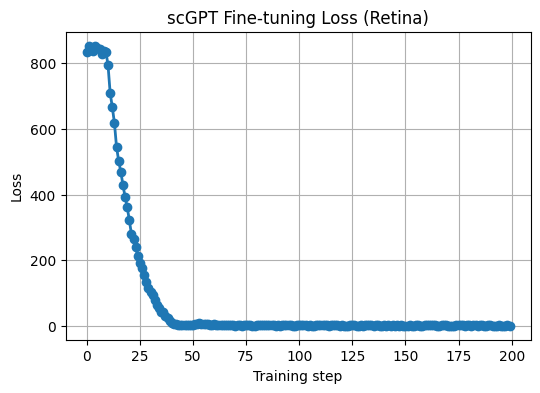

Saved figure to figures/scgpt_finetuning_loss_retina.png


In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(step_hist, loss_hist, marker="o", linewidth=2)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("scGPT Fine-tuning Loss (Retina)")
plt.grid(True)

# Save figure (important for Slack / reports)
plt.savefig("figures/scgpt_finetuning_loss_retina.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure to figures/scgpt_finetuning_loss_retina.png")

In [32]:
import os
save_path = "scgpt_finetuned_retina.pt"
torch.save(model.state_dict(), save_path)
print("saved:", save_path)

saved: scgpt_finetuned_retina.pt


In [33]:
def extract_cell_emb_all(model, X, token_ids, pad_token_id, max_len=256, batch=1, device="cuda"):
    """
    Extract cell embeddings for all cells using a trained (or fine-tuned) model.
    """
    model = model.to(device).eval()
    n = X.shape[0]
    all_emb = []

    with torch.inference_mode():
        for start in range(0, n, batch):
            end = min(n, start + batch)

            Xb = X[start:end]
            if sp.issparse(Xb):
                Xb = Xb.toarray()
            Xb = Xb.astype(np.float32)

            # Convert expression matrix to token sequence format
            src_bs, val_bs, mask_bs = batch_to_topk_seq(
                Xb, token_ids, max_len, pad_token_id
            )

            # numpy -> torch (B, S)
            src = torch.from_numpy(src_bs).to(device=device, dtype=torch.long)        # (B, S)
            values = torch.from_numpy(val_bs).to(device=device, dtype=torch.float32)  # (B, S)
            mask = torch.from_numpy(mask_bs).to(device=device, dtype=torch.bool)      # (B, S)

            # Forward pass to extract cell embeddings
            out = model(
                src=src,
                values=values,
                src_key_padding_mask=mask,
                batch_labels=None,
                CLS=True
            )

            emb = out["cell_emb"].detach().float().cpu().numpy()   # (B, 512)
            all_emb.append(emb)

            # Free GPU memory
            del src, values, mask, out
            if device == "cuda":
                torch.cuda.empty_cache()

    return np.vstack(all_emb)


# Extract embeddings using the fine-tuned model
emb = extract_cell_emb_all(
    model,
    adata2.X,
    token_ids,
    pad_token_id,
    max_len=MAX_LEN,
    batch=1,
    device=device
)

print("X_scGPT finetuned:", emb.shape)

# Store embeddings in AnnData
adata2.obsm["X_scGPT_finetuned"] = emb

# Save results
adata2.write_h5ad("retina_scgpt_cell_emb_finetuned.h5ad")
print("saved: retina_scgpt_cell_emb_finetuned.h5ad")

X_scGPT finetuned: (20587, 512)
saved: retina_scgpt_cell_emb_finetuned.h5ad
